In [14]:
import sys
import os
os.environ['PROJ_DATA'] = "/pscratch/sd/p/plutzner/proj_data"
import xarray as xr
import torch
import torchinfo
import random
import numpy as np
import importlib as imp
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import cartopy.crs as ccrs
import json
import pickle
import gzip
import scipy
import cftime
from scipy import stats
from cftime import DatetimeNoLeap
from datetime import datetime
from sklearn.metrics import mean_squared_error
#import matplotlib.colors as mcolorsxx

# %load_ext autoreload
# %autoreload 2
import utils
import utils.filemethods as filemethods
import databuilder.data_loader as data_loader
from utils.filemethods import open_data_file
from utils import utils


"""
(1) Open 0101 and 0151 data files containing Z500, PRECT, TS
(2) Check the files for correct magnitudes and variables
(3) Shift 0101 data by -60225 days to 1685-1849
(4) Merge the two datasets into a single dataset with continuous time (1685 - 2014)
(5) Save the merged dataset to a new NetCDF file
(6) Print the shape of the merged dataset
(7) Print the time range of the merged dataset
xvariable names in the merged dataset

"""
    

'\n(1) Open 0101 and 0151 data files containing Z500, PRECT, TS\n(2) Check the files for correct magnitudes and variables\n(3) Shift 0101 data by -60225 days to 1685-1849\n(4) Merge the two datasets into a single dataset with continuous time (1685 - 2014)\n(5) Save the merged dataset to a new NetCDF file\n(6) Print the shape of the merged dataset\n(7) Print the time range of the merged dataset\nxvariable names in the merged dataset\n\n'

In [12]:
def merge_input_files(training_file, val_file, output_file):
    # Open the training data file
    ds_train = open_data_file(training_file)
    ds_train_input = ds_train['x']

    # Select only 1850-2014 (not 2015)
    ds_train_input = ds_train_input.sel(time=slice('1850-01-01', '2014-12-31'))

    # Open the validation data file
    ds_val = open_data_file(val_file)
    ds_val_input = ds_val['x']

    # Shift the time in the test dataset by -60225 days
    # Datetime no leap is used to avoid leap years in the time series
    print("Time range of train dataset before shift:", ds_train_input['time'].values.min(), "to", ds_train_input['time'].values.max())
    ds_train_input['time'] = xr.cftime_range(start='1685-01-01', 
                                       end='1849-12-31', 
                                       freq='D',
                                       calendar='noleap')

    print("Time range of train dataset after shift:", ds_train_input['time'].values.min(), "to", ds_train_input['time'].values.max())

    print(f"ds_train_input: {ds_train_input}")

    # Data is in the form [time, lat, lon, channel] in ['x'], and [time] in ['y']
    # Merge the two datasets along the time dimension
    ds_merged_training = xr.merge([ds_train_input, ds_val_input], compat='override')
    
    print(f"ds_merged_training: {ds_merged_training}")

    # # Assign the merged time coordinate to the merged dataset
    # ds_merged_training = ds_merged_training.assign_coords(time=merged_time) ? 

    # shift and merge target too: 
    ds_train_target = ds_train['y']
    ds_val_target = ds_val['y']

    ds_train_target['time'] = ds_train_input['time']

    ds_merged_training_target =  xr.merge([ds_train_target, ds_val_target], compat='override')
    print(f"ds_merged_training_target: {ds_merged_training_target}")
    print(f"ds_merged_Training_target time: {ds_merged_training_target.time}")

    # Save the merged dataset to a new pkl file maintingin the ['x'] and ['y'] dictionary structure

    d_train_new = {
        'x': ds_merged_training,
        'y': ds_merged_training_target
    }

    if np.any(np.isnan(d_train_new['x'])):
        print("Input data has nans")
        # print location of nans
        nan_locations = np.where(np.isnan(d_train_new['x']))
        print(nan_locations)

In [20]:
train_fn = '/pscratch/sd/p/plutzner/E3SM/bigdata/presaved/exp140_trimmed_train_dat.nc'
val_fn = '/pscratch/sd/p/plutzner/E3SM/bigdata/presaved/exp140_trimmed_val_dat.nc'
test_fn = '/pscratch/sd/p/plutzner/E3SM/bigdata/presaved/exp140_trimmed_test_dat.nc'

output_fn = '/pscratch/sd/p/plutzner/E3SM/bigdata/presaved/exp140_d_train_merged.pkl'
merge_input_files(train_fn, val_fn, output_fn)

Time range of train dataset before shift: 1850-02-12 00:00:00 to 2014-12-17 00:00:00


ValueError: conflicting sizes for dimension 'time': length 29974 on <this-array> and length 60225 on {'lat': 'lat', 'lon': 'lon', 'channel': 'channel', 'time': 'time'}

In [5]:
test_fn = '/pscratch/sd/p/plutzner/E3SM/bigdata/presaved/exp140_d_test.pkl'

# Split testing dataset into two halves: 
new_validation_dates = [1850, 1931]
new_test_dates = [1932, 2014]

# load testing dataset
original_testing = open_data_file(test_fn)

# Select the new validation and test periods
new_val_input = original_testing['x'].sel(time=slice(f"{new_validation_dates[0]}-01-01", f"{new_validation_dates[1]}-12-31"))
new_val_target = original_testing['y'].sel(time=slice(f"{new_validation_dates[0]}-01-01", f"{new_validation_dates[1]}-12-31"))
new_test_input = original_testing['x'].sel(time=slice(f"{new_test_dates[0]}-01-01", f"{new_test_dates[1]}-12-31"))
new_test_target = original_testing['y'].sel(time=slice(f"{new_test_dates[0]}-01-01", f"{new_test_dates[1]}-12-31"))

# save the new validation and test datasets as pkl
new_val_data = {
    'x': new_val_input,
    'y': new_val_target
}
new_test_data = {
    'x': new_test_input,
    'y': new_test_target
}
new_val_fn = '/pscratch/sd/p/plutzner/E3SM/bigdata/presaved/exp140_d_val_modified.pkl'
new_test_fn = '/pscratch/sd/p/plutzner/E3SM/bigdata/presaved/exp140_d_test_modified.pkl'

with open(new_val_fn, 'wb') as f:
    pickle.dump(new_val_data, f, protocol=pickle.HIGHEST_PROTOCOL)

with open(new_test_fn, 'wb') as f:
    pickle.dump(new_test_data, f, protocol=pickle.HIGHEST_PROTOCOL)

### Checking inputs for nans - none

In [21]:
exp140 = open_data_file('/pscratch/sd/p/plutzner/E3SM/bigdata/presaved/exp144_trimmed_train_dat.nc')

In [22]:
if np.any(np.isnan(exp140['x'])):
    print("Input data has nans")
    # print location of nans
    nan_locations = np.where(np.isnan(exp140['x']))
    print(nan_locations)

In [23]:
exp140_val = open_data_file('/pscratch/sd/p/plutzner/E3SM/bigdata/presaved/exp144_trimmed_val_dat.nc')

if np.any(np.isnan(exp140_val['x'])):
    print("Input data has nans")
    # print location of nans
    nan_locations = np.where(np.isnan(exp140_val['x']))
    print(nan_locations)

In [24]:
exp140_test = open_data_file('/pscratch/sd/p/plutzner/E3SM/bigdata/presaved/exp144_trimmed_test_dat.nc')

if np.any(np.isnan(exp140_test['x'])):
    print("Input data has nans")
    # print location of nans
    nan_locations = np.where(np.isnan(exp140_test['x']))
    print(nan_locations)

In [26]:
exp140

<xarray.Dataset> Size: 8GB
Dimensions:        (time: 10711, lat: 181, lon: 360, channel: 3)
Coordinates:
  * time           (time) datetime64[ns] 86kB 1940-01-29 ... 1998-12-17
    isobaricInhPa  float64 8B ...
  * lat            (lat) float64 1kB 90.0 89.0 88.0 87.0 ... -88.0 -89.0 -90.0
  * lon            (lon) float64 3kB 0.0 1.0 2.0 3.0 ... 356.0 357.0 358.0 359.0
  * channel        (channel) int64 24B 0 1 2
Data variables:
    x              (time, lat, lon, channel) float32 8GB -0.149 2.446 ... 83.01
    y              (time) float64 86kB ...

In [30]:
exp140_shifted = open_data_file('/pscratch/sd/p/plutzner/E3SM/bigdata/presaved/exp140_trimmed_train_dat_new.nc')
exp140_shifted.time
exp140_shifted['x']

<xarray.DataArray 'x' (time: 59948, lat: 180, lon: 360, channel: 2)> Size: 62GB
[7769260800 values with dtype=float64]
Coordinates:
  * time     (time) object 480kB 1685-02-12 00:00:00 ... 2014-12-17 00:00:00
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * channel  (channel) float64 16B 0.0 1.0

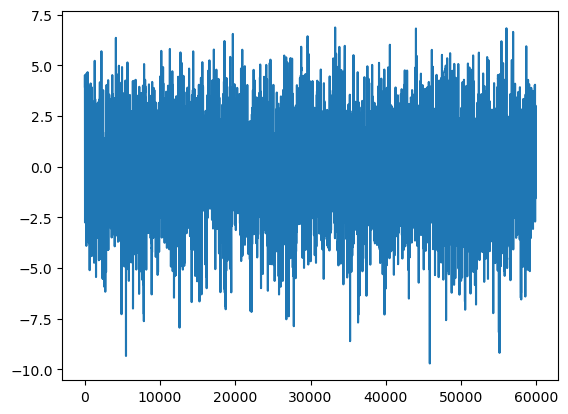

In [39]:
plt.figure()
plt.plot(exp140_shifted['x'][..., 1].sel(lat = 40.5, lon = 100.5))

In [50]:
exp148_val = open_data_file('/pscratch/sd/p/plutzner/E3SM/bigdata/presaved/exp148_trimmed_val_dat.nc')

In [56]:
exp148_val['y']

<xarray.DataArray 'y' (time: 14882)> Size: 119kB
[14882 values with dtype=float64]
Coordinates:
  * time     (time) object 119kB 1850-02-12 00:00:00 ... 1931-12-31 00:00:00

In [57]:
exp148_test = open_data_file('/pscratch/sd/p/plutzner/E3SM/bigdata/presaved/exp148_trimmed_test_dat.nc')
exp148_test['y']

<xarray.DataArray 'y' (time: 15092)> Size: 121kB
[15092 values with dtype=float64]
Coordinates:
  * time     (time) object 121kB 1932-01-01 00:00:00 ... 2014-12-17 00:00:00

In [30]:
exp154_train = open_data_file('/pscratch/sd/p/plutzner/E3SM/bigdata/presaved/exp154_trimmed_train_dat.nc')

In [31]:
exp154_train['x']

<xarray.DataArray 'x' (time: 59976, lat: 180, lon: 360, channel: 3)> Size: 93GB
[11659334400 values with dtype=float64]
Coordinates:
  * time     (time) object 480kB 1685-01-29 00:00:00 ... 2014-12-17 00:00:00
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * channel  (channel) float64 24B 0.0 1.0 2.0

In [5]:
exp154_val = open_data_file('/pscratch/sd/p/plutzner/E3SM/bigdata/presaved/exp154_trimmed_val_dat.nc')

In [13]:
exp154_val['x']

<xarray.DataArray 'x' (time: 14896, lat: 180, lon: 360, channel: 3)> Size: 23GB
array([[[[-1.301747e-01, ..., -1.153811e+00],
         ...,
         [-1.302548e-01, ..., -1.143477e+00]],

        ...,

        [[ 3.518287e-02, ..., -4.935681e+01],
         ...,
         [ 3.385294e-02, ..., -4.944611e+01]]],


       ...,


       [[[-1.494041e-01, ...,  6.187571e+01],
         ...,
         [-1.497016e-01, ...,  6.186200e+01]],

        ...,

        [[-1.661549e-01, ...,  3.485360e+01],
         ...,
         [-1.627651e-01, ...,  3.468196e+01]]]])
Coordinates:
  * time     (time) object 119kB 1850-01-29 00:00:00 ... 1931-12-31 00:00:00
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * channel  (channel) float64 24B 0.0 1.0 2.0

In [10]:
exp154_test = open_data_file('/pscratch/sd/p/plutzner/E3SM/bigdata/presaved/exp154_trimmed_test_dat.nc')

In [12]:
exp154_test['y']

<xarray.DataArray 'y' (time: 15092)> Size: 121kB
[15092 values with dtype=float64]
Coordinates:
  * time     (time) object 121kB 1932-01-01 00:00:00 ... 2014-12-17 00:00:00

In [22]:
fixed_file = open_data_file('/pscratch/sd/p/plutzner/E3SM/bigdata/presaved/exp154_trimmed_train_dat.nc')

In [23]:
fixed_file['x']

<xarray.DataArray 'x' (time: 59976, lat: 180, lon: 360, channel: 3)> Size: 93GB
[11659334400 values with dtype=float64]
Coordinates:
  * time     (time) object 480kB 1685-01-29 00:00:00 ... 2014-12-17 00:00:00
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * channel  (channel) float64 24B 0.0 1.0 2.0

In [32]:
train = open_data_file('/pscratch/sd/p/plutzner/E3SM/bigdata/presaved/exp154_trimmed_train_dat.nc')

In [38]:
train['x'].sel(time = '1686-01-01').values

array([[[[ 1.66672894e-02, -1.45414400e+00, -2.72807922e+01],
         [ 1.72198185e-02, -1.44419992e+00, -2.72349148e+01],
         [ 1.77717382e-02, -1.43426096e+00, -2.71889248e+01],
         ...,
         [ 1.50110694e-02, -1.48400021e+00, -2.74194126e+01],
         [ 1.55624398e-02, -1.47405183e+00, -2.73728237e+01],
         [ 1.61146677e-02, -1.46410012e+00, -2.73268261e+01]],

        [[ 7.16085685e-02, -6.75149262e-01, -3.52222099e+01],
         [ 7.23522963e-02, -6.52810752e-01, -3.50667534e+01],
         [ 7.30749093e-02, -6.30843282e-01, -3.49081764e+01],
         ...,
         [ 6.92455039e-02, -7.44341552e-01, -3.56713638e+01],
         [ 7.00556803e-02, -7.20922530e-01, -3.55247612e+01],
         [ 7.08431969e-02, -6.97854519e-01, -3.53752403e+01]],

        [[ 1.22750656e-01, -4.39437598e-01, -3.99426804e+01],
         [ 1.23040221e-01, -4.07679349e-01, -3.96073074e+01],
         [ 1.23286382e-01, -3.74737829e-01, -3.92727585e+01],
         ...,
         [ 1.21598574e-0